In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\muhammed suhail\Desktop\Customer_Churn_Analysis\data\churn.csv ")
df.columns = df.columns.str.strip()
print(df.shape)
print(df.columns)


(7043, 38)
Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='object')


In [5]:
print(df.head(5))

  Customer ID  Gender  Age Married  Number of Dependents          City  \
0  0002-ORFBO  Female   37     Yes                     0  Frazier Park   
1  0003-MKNFE    Male   46      No                     0      Glendale   
2  0004-TLHLJ    Male   50      No                     0    Costa Mesa   
3  0011-IGKFF    Male   78     Yes                     0      Martinez   
4  0013-EXCHZ  Female   75     Yes                     0     Camarillo   

   Zip Code   Latitude   Longitude  Number of Referrals  ...   Payment Method  \
0     93225  34.827662 -118.999073                    2  ...      Credit Card   
1     91206  34.162515 -118.203869                    0  ...      Credit Card   
2     92627  33.645672 -117.922613                    0  ...  Bank Withdrawal   
3     94553  38.014457 -122.115432                    1  ...  Bank Withdrawal   
4     93010  34.227846 -119.079903                    3  ...      Credit Card   

  Monthly Charge Total Charges  Total Refunds Total Extra Data Charg

In [6]:
df['Churn'] = df['Churn Category'].apply(lambda x: 0 if x == 'No Churn' else 1)
print(df['Churn'].value_counts())

Churn
1    7043
Name: count, dtype: int64


In [7]:
# convert Totalcharges(if exists)
if 'TotalCharges' in df.columns:
    df['TotalCharges']= pd.to_numeric(df['TotalCharges'],errors='coerce')

# Drop missing
df.dropna(inplace=True)

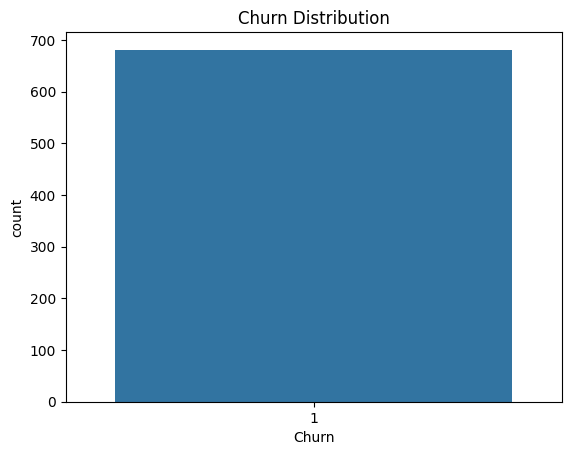

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

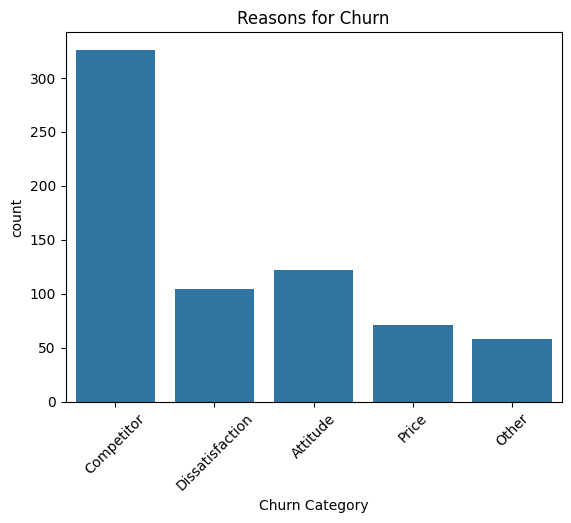

In [9]:
sns.countplot(x='Churn Category', data=df)
plt.xticks(rotation=45)
plt.title("Reasons for Churn")
plt.show()

In [21]:
print(df.columns.tolist())

['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason', 'Churn']


In [25]:
df.columns = df.columns.str.strip()

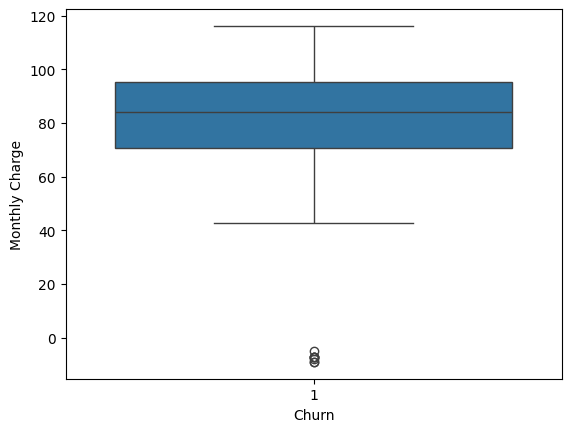

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='Monthly Charge', data=df)
plt.show()


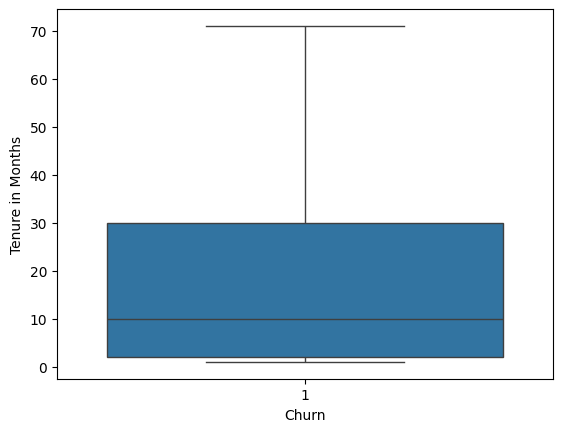

In [33]:
sns.boxplot(x='Churn', y='Tenure in Months', data=df)
plt.show()

In [36]:
df['Tenure_group'] = pd.cut(
    df['Tenure in Months'],
    bins=[0, 12, 24, 48, 60, 100],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5+yr']
)

In [37]:
df['avg_spend'] = (
    df['Monthly Charge'] + 
    df['Avg Monthly Long Distance Charges']
)

In [40]:
df['Total Revenue'] = (
    df['Tenure in Months'] *
    df['avg_spend']
)

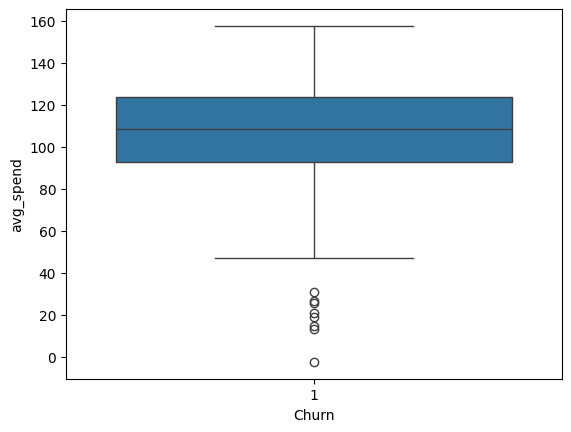

In [41]:
sns.boxplot(x='Churn', y='avg_spend',data=df)
plt.show()

In [46]:
df = pd.get_dummies(df, drop_first=True)

In [60]:
df['Churn'].value_counts()

Churn
1    681
Name: count, dtype: int64

In [67]:
print(df.isnull().sum())

Age                                     0
Number of Dependents                    0
Zip Code                                0
Latitude                                0
Longitude                               0
                                       ..
Churn Reason_Service dissatisfaction    0
Tenure_group_1-2yr                      0
Tenure_group_2-4yr                      0
Tenure_group_4-5yr                      0
Tenure_group_5+yr                       0
Length: 1139, dtype: int64


In [68]:
X = df.drop('Churn', axis=1)
print(X.dtypes)

Age                                       int64
Number of Dependents                      int64
Zip Code                                  int64
Latitude                                float64
Longitude                               float64
                                         ...   
Churn Reason_Service dissatisfaction       bool
Tenure_group_1-2yr                         bool
Tenure_group_2-4yr                         bool
Tenure_group_4-5yr                         bool
Tenure_group_5+yr                          bool
Length: 1138, dtype: object


In [69]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [73]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


In [76]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       137

    accuracy                           1.00       137
   macro avg       1.00      1.00      1.00       137
weighted avg       1.00      1.00      1.00       137



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


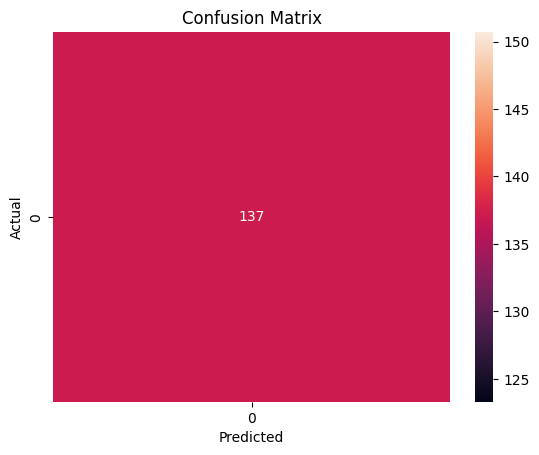

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [81]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

Age                    0.0
City_Cedar Glen        0.0
City_Clarksburg        0.0
City_Claremont         0.0
City_Citrus Heights    0.0
City_Chula Vista       0.0
City_Chualar           0.0
City_Challenge         0.0
City_Catheys Valley    0.0
City_Clipper Mills     0.0
dtype: float64


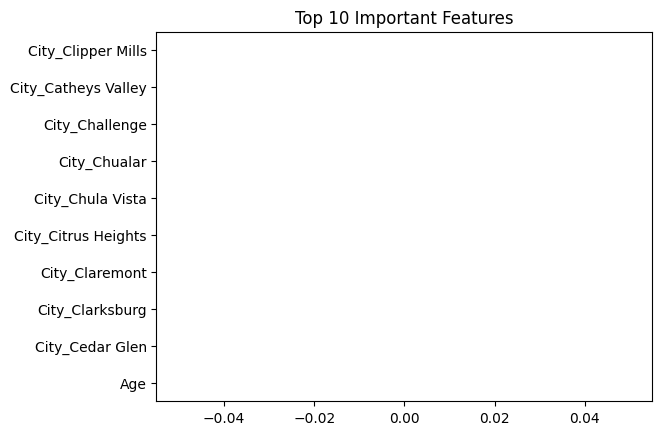

In [82]:
importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [84]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob

IndexError: index 1 is out of bounds for axis 1 with size 1